In [2]:
from wavediffusion.wavedata import npyDataResized, npyDataWndHist
from torch.utils.data import DataLoader
from wavediffusion.model import Scaled
from wavediffusion.model_unet import myUnet
from torch_ema import ExponentialMovingAverage as EMA
import torch
import numpy as np
import os
from matplotlib import pyplot as plt
from wavediffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, ScheduleLDM
from accelerate import Accelerator

%load_ext autoreload
%autoreload 2

### Choose case and checkpoint

#### Without history

In [2]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [('wave_200804', 'forcing_200804')]
stats_file = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']

### Construct test dataset
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataResized(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True,
    compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf
)

In [3]:
RESUME = True
epoch = 16
path = '../run/global/log1p/DDPM3/'
weights_file = path + f'ckpt_{epoch}.pt'

# model = Scaled(myUnet)(in_dim=320, in_ch=4, out_ch=4, ch=128, precond_ch=3, 
#                        scale=(test.meanx, test.stdx, test.meanf, test.stdf),
#                        ch_mult=(1, 2, 2, 2), attn_resolutions=(16,))  

model = Scaled(myUnet)(in_dim=320, in_ch=4, out_ch=4, ch=192, precond_ch=3, 
                       scale=(test.meanx, test.stdx, test.meanf, test.stdf),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,)) 

#### With history

In [2]:
# Normalization
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
# stats_file = os.path.join(train_file_path, 'stats.npz')
# stats = np.load(stats_file)
# meanx, stdx = stats['meanx'], stats['stdx']
# meanf, stdf = stats['meanf'], stats['stdf']

stats_file1 = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file1)
meanf, stdf = stats['meanf'], stats['stdf']
stats_file2 = os.path.join(train_file_path, 'stats_parts.npz')
stats_parts = np.load(stats_file2)
meanx, stdx = stats_parts['meanparts'], stats_parts['stdparts']

test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [('waveparts_200404', 'forcing_200404')]
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataWndHist(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=3
)

In [3]:
RESUME = True
epoch = 28
# path = '/global/homes/j/jiarongw/scratch_folder/log1p/hist1/'
path = '/global/homes/j/jiarongw/scratch_folder/log1p/waveparts_hist/'
weights_file = path + f'ckpt_{epoch}.pt'

model = Scaled(myUnet)(in_dim=320, in_ch=7, out_ch=7, ch=256, precond_ch=13, 
                       scale=(test.meanx, test.stdx, test.meanf, test.stdf),
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))  

### Compute noise level loss

In [4]:
fnumber = 7
ema = EMA(model.parameters(), decay=0.999)
    
if RESUME:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])

loader_test = DataLoader(test, batch_size=10, shuffle=True)
a = Accelerator()
model, loader_test = a.prepare(model, loader_test)
ema.to(a.device)

loader_test_iter = iter(loader_test)
x, f, mask = next(loader_test_iter)

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)

import torch.nn as nn
losses = torch.zeros([fnumber, len(schedule.sigmas)])
with torch.no_grad():
    for i, s in enumerate(schedule.sigmas):
        print(f'Loss level {i}...')
        sigma = s.expand(x.shape[0]).to(x)
        while len(sigma.shape) < len(x.shape):
            sigma = sigma.unsqueeze(-1)
        eps = torch.randn_like(x)
        eps = eps * mask
        pred_eps = model.forward(x + sigma * eps, sigma, cond=f) * mask
        print(nn.MSELoss()(eps, pred_eps))
        for j in range(0, fnumber): # Field wise loss
            losses[j, i] = nn.MSELoss()(eps[:,j], pred_eps[:,j])
        print(torch.mean(losses[:,i]))
     
torch.save(losses, path + f'noise_level_loss_by_field_epoch{epoch}.pt')

/global/u1/j/jiarongw/wavediffusion/src/wavediffusion/wavedata.py:397: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /mscratch/sd/s/swowner/pytorch-build/pytorch/2.6.0/pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  f = torch.from_numpy(self.F_files[file_idx][local_idx]).float()


Loss level 0...
tensor(0.3719, device='cuda:0')
tensor(0.3719)
Loss level 1...
tensor(0.3000, device='cuda:0')
tensor(0.3000)
Loss level 2...
tensor(0.2368, device='cuda:0')
tensor(0.2368)
Loss level 3...
tensor(0.1838, device='cuda:0')
tensor(0.1838)
Loss level 4...
tensor(0.1408, device='cuda:0')
tensor(0.1408)
Loss level 5...
tensor(0.1071, device='cuda:0')
tensor(0.1071)
Loss level 6...
tensor(0.0808, device='cuda:0')
tensor(0.0808)
Loss level 7...
tensor(0.0595, device='cuda:0')
tensor(0.0595)
Loss level 8...
tensor(0.0427, device='cuda:0')
tensor(0.0427)
Loss level 9...
tensor(0.0292, device='cuda:0')
tensor(0.0292)
Loss level 10...
tensor(0.0190, device='cuda:0')
tensor(0.0190)
Loss level 11...
tensor(0.0116, device='cuda:0')
tensor(0.0116)
Loss level 12...
tensor(0.0068, device='cuda:0')
tensor(0.0068)
Loss level 13...
tensor(0.0039, device='cuda:0')
tensor(0.0039)
Loss level 14...
tensor(0.0023, device='cuda:0')
tensor(0.0023)
Loss level 15...
tensor(0.0014, device='cuda:0')
t

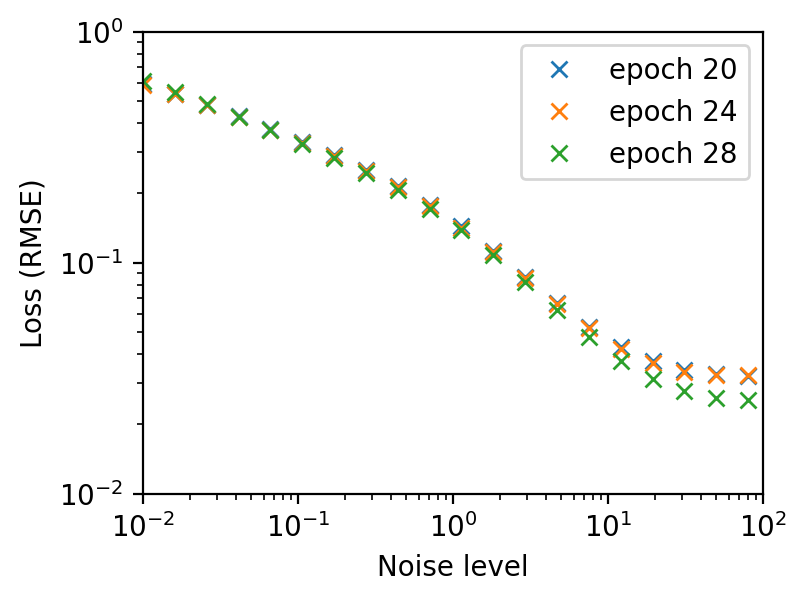

In [5]:
# Read from file
path = '/global/homes/j/jiarongw/scratch_folder/'
loss1 = torch.load(path + 'log1p/waveparts_hist/noise_level_loss_by_field_epoch20.pt')
loss2 = torch.load(path + 'log1p/waveparts_hist/noise_level_loss_by_field_epoch24.pt')
loss3 = torch.load(path + 'log1p/waveparts_hist/noise_level_loss_by_field_epoch28.pt')

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)

plt.figure(figsize=[4,3],dpi=200)
plt.plot(schedule.sigmas, torch.mean(loss1, dim=0)**0.5, 'x', label='epoch 20')
plt.plot(schedule.sigmas, torch.mean(loss2, dim=0)**0.5, 'x', label='epoch 24')
plt.plot(schedule.sigmas, torch.mean(loss3, dim=0)**0.5, 'x', label='epoch 28 (change to DDPM)')

plt.yscale('log'); 
plt.ylim([10**-2, 10**0])
plt.xscale('log'); 
plt.xlim([10**-2, 10**2])

plt.xlabel('Noise level')
plt.ylabel('Loss (RMSE)')
plt.legend()

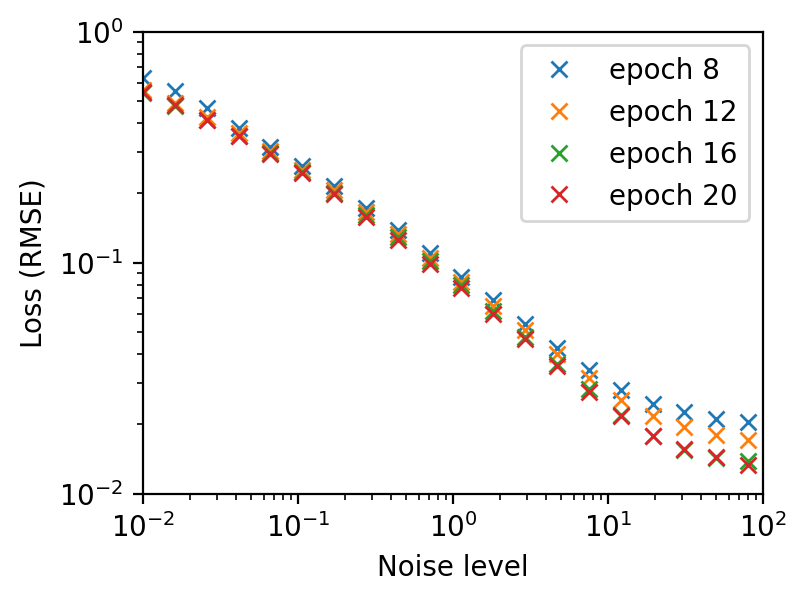

In [24]:
# Read from file
path = '/global/homes/j/jiarongw/scratch_folder/'
loss1 = torch.load(path + 'log1p/hist1/noise_level_loss_by_field_epoch8.pt')
loss3 = torch.load(path + 'log1p/hist1/noise_level_loss_by_field_epoch12.pt')
loss4 = torch.load(path + 'log1p/hist1/noise_level_loss_by_field_epoch16.pt')
loss5 = torch.load(path + 'log1p/hist1/noise_level_loss_by_field_epoch20.pt')

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)

plt.figure(figsize=[4,3],dpi=200)
plt.plot(schedule.sigmas, torch.mean(loss1, dim=0)**0.5, 'x', label='epoch 8')
plt.plot(schedule.sigmas, torch.mean(loss3, dim=0)**0.5, 'x', label='epoch 12')
plt.plot(schedule.sigmas, torch.mean(loss4, dim=0)**0.5, 'x', label='epoch 16')
plt.plot(schedule.sigmas, torch.mean(loss5, dim=0)**0.5, 'x', label='epoch 20')
# plt.plot(schedule.sigmas, torch.mean(loss1, dim=0), 'x', label='epoch 8')
# plt.plot(schedule.sigmas, torch.mean(loss3, dim=0), 'x', label='epoch 12')
# plt.plot(schedule.sigmas, torch.mean(loss4, dim=0), 'x', label='epoch 16')
# plt.plot(schedule.sigmas, torch.mean(loss5, dim=0), 'x', label='epoch 20')

plt.yscale('log'); 
plt.ylim([10**-2, 10**0])
plt.xscale('log'); 
plt.xlim([10**-2, 10**2])

plt.xlabel('Noise level')
plt.ylabel('Loss (RMSE)')
plt.legend()

/tmp/ipykernel_1761747/1631641391.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


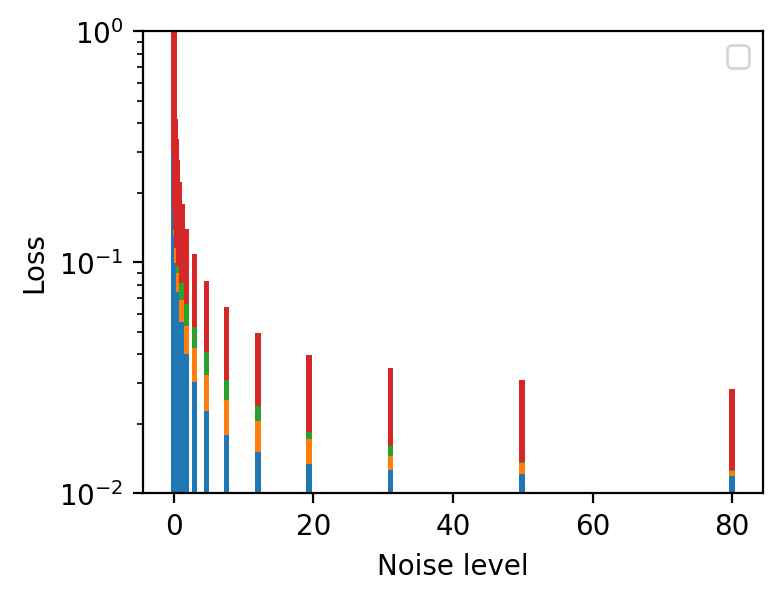

In [30]:
# Read from file
path = '/global/homes/j/jiarongw/scratch_folder/'

loss5 = torch.load(path + 'log1p/hist1/noise_level_loss_by_field_epoch20.pt')

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)

plt.figure(figsize=[4,3],dpi=200)

plt.bar(schedule.sigmas, loss5[0]**0.5)
plt.bar(schedule.sigmas, loss5[1]**0.5, bottom = loss5[0]**0.5)
plt.bar(schedule.sigmas, loss5[2]**0.5, bottom = loss5[1]**0.5)
plt.bar(schedule.sigmas, loss5[3]**0.5, bottom = loss5[2]**0.5)
# ax.bar(groups, values1)
# ax.bar(groups, values2, bottom = values1)

# plt.plot(schedule.sigmas, torch.mean(loss1, dim=0)**0.5, 'x', label='epoch 8')
# plt.plot(schedule.sigmas, torch.mean(loss3, dim=0)**0.5, 'x', label='epoch 12')
# plt.plot(schedule.sigmas, torch.mean(loss4, dim=0)**0.5, 'x', label='epoch 16')
# plt.plot(schedule.sigmas, torch.mean(loss5, dim=0)**0.5, 'x', label='epoch 20')

plt.yscale('log'); plt.ylim([10**-2, 10**0])
# plt.xscale('log'); plt.xlim([10**-2, 10**2])
plt.xlabel('Noise level')
plt.ylabel('Loss')
plt.legend()

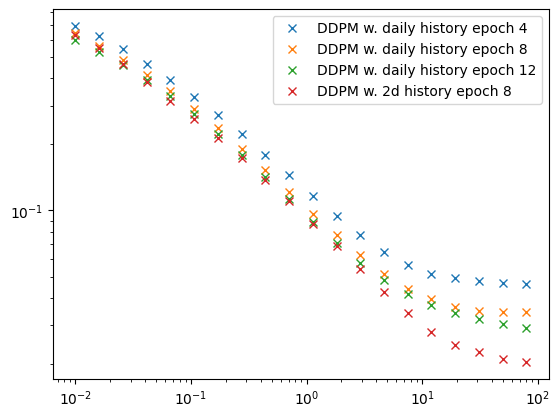

In [9]:
# Read from file
path = '/global/homes/j/jiarongw/scratch_folder/'
loss1 = torch.load(path + 'log1p/hist2/noise_level_loss_by_field_epoch4.pt')
loss2 = torch.load(path + 'log1p/hist2/noise_level_loss_by_field_epoch8.pt')
loss3 = torch.load(path + 'log1p/hist2/noise_level_loss_by_field_epoch12.pt')

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)
plt.plot(schedule.sigmas, torch.mean(loss1, dim=0)**0.5, 'x', label='DDPM w. daily history epoch 4')
plt.plot(schedule.sigmas, torch.mean(loss2, dim=0)**0.5, 'x', label='DDPM w. daily history epoch 8')
plt.plot(schedule.sigmas, torch.mean(loss3, dim=0)**0.5, 'x', label='DDPM w. daily history epoch 12')

path = '/global/homes/j/jiarongw/scratch_folder/'
loss1 = torch.load(path + 'log1p/hist1/noise_level_loss_by_field_epoch8.pt')
schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)
plt.plot(schedule.sigmas, torch.mean(loss1, dim=0)**0.5, 'x', label='DDPM w. 2d history epoch 8')

plt.yscale('log')
plt.xscale('log')
plt.legend()


### Loss averaged across four fields

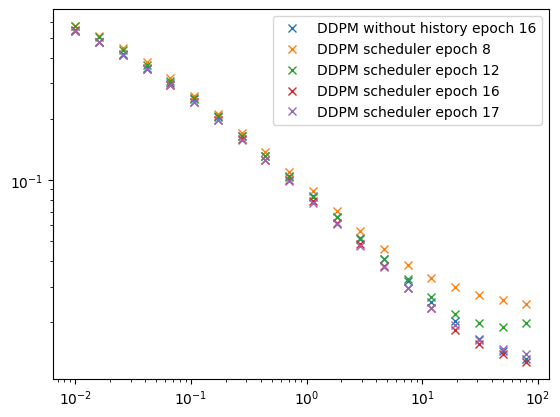

In [25]:
# plt.plot(schedule.sigmas, torch.tensor(loss1)**0.5, '+', label='Loglinear scheduler epoch 4')
# plt.plot(schedule.sigmas, torch.tensor(loss2)**0.5, '+', label='Loglinear scheduler epoch 8')
# plt.plot(schedule.sigmas, torch.tensor(loss3)**0.5, 'x', label='DDPM scheduler epoch 8')
# plt.plot(schedule.sigmas, torch.tensor(loss4)**0.5, 'x', label='DDPM scheduler epoch 12')
# plt.plot(schedule.sigmas, torch.mean(loss5_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 16')
# plt.plot(schedule.sigmas, torch.mean(loss6_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 24')

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=80, N=20)
plt.plot(schedule.sigmas, torch.mean(loss9_, dim=0)**0.5, 'x', label='DDPM without history epoch 16')
plt.plot(schedule.sigmas, torch.mean(loss10_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 8')
plt.plot(schedule.sigmas, torch.mean(loss11_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 12')
plt.plot(schedule.sigmas, torch.mean(loss12_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 16')
plt.plot(schedule.sigmas, torch.mean(loss13_, dim=0)**0.5, 'x', label='DDPM scheduler epoch 17')


plt.yscale('log')
plt.xscale('log')
plt.legend()

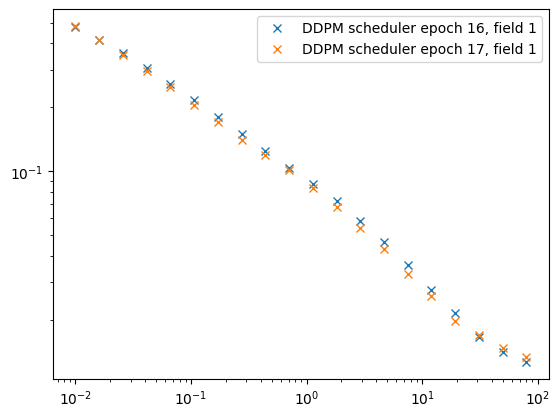

In [28]:
plt.plot(schedule.sigmas, (loss9_[2])**0.5, 'x', label='DDPM scheduler epoch 16, field 1')
plt.plot(schedule.sigmas, (loss12_[2])**0.5, 'x', label='DDPM scheduler epoch 17, field 1')
plt.yscale('log')
plt.xscale('log')
plt.legend()

In [33]:
sigma = schedule.sample_batch(x)
print(sigma.shape)

torch.Size([20])


In [ ]:
loader_test = DataLoader(test, batch_size=10, shuffle=True)
for x, f, mask in loader_test:
    x_masked = x * mask
    eps = torch.randn_like(x)
    size1 = torch.max(abs(x_masked[:,1,:,:]))
    size2 = torch.max(abs(eps[:,1,:,:]))
    print(size1, size2)

(0.0, 40.0)

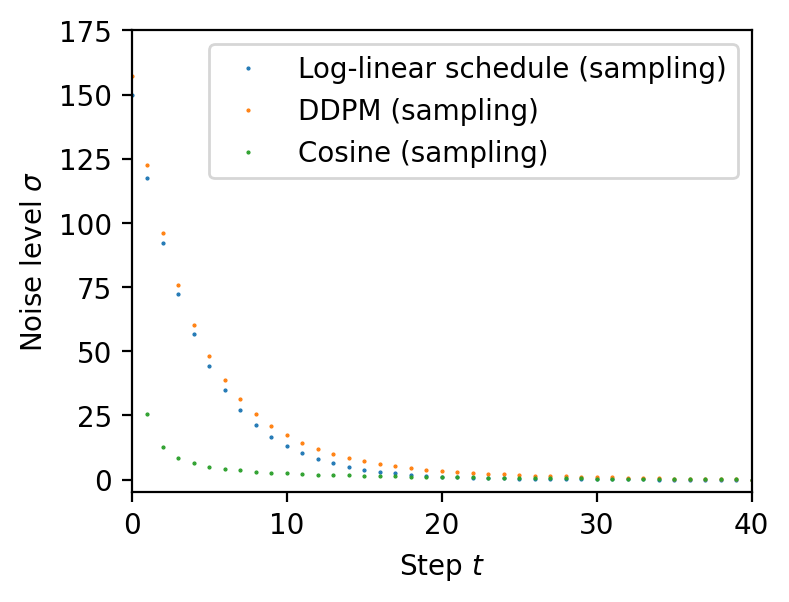

In [3]:
from wavediffusion.diffusion import ScheduleLogLinear, ScheduleDDPM, ScheduleLDM, ScheduleCosine
schedule1 = ScheduleLogLinear(sigma_min=0.01, sigma_max=150, N=80)
schedule2 = ScheduleDDPM()
schedule3 = ScheduleCosine()
sigmas1 = schedule1.sample_sigmas(40)
sigmas2 = schedule2.sample_sigmas(40)
sigmas3 = schedule3.sample_sigmas(40)
plt.figure(figsize=[4,3], dpi=200)
# plt.plot(np.array(schedule2.sigmas)[::-1], '.', markersize=1, label='DDPM schedule (training)')
plt.plot(sigmas1, '.', markersize=1, label='Log-linear schedule (sampling)')
plt.plot(sigmas2, '.', markersize=1, label='DDPM (sampling)')
plt.plot(sigmas3, '.', markersize=1, label='Cosine (sampling)')
plt.legend()
plt.xlabel(r'Step $t$')
plt.ylabel(r'Noise level $\sigma$')
plt.ylim([-5,175]) 
plt.xlim([0,40])